# Modelling

**Tujuan**: Melatih dan mengevaluasi 4 algoritma klasifikasi (KNN, Naive Bayes, Logistic Regression, Decision Tree) untuk sentimen & emosi pada ulasan e-commerce.

**Experimental Design (Factorial)**:
- Faktor 1: Algoritma (4 level: KNN, Naive Bayes, Logistic Regression, Decision Tree)
- Faktor 2: Varian Fitur (2-3 level tergantung task)
- Faktor 3: Penanganan Imbalance (tanpa SMOTE / dengan SMOTE, dan ADASYN untuk improved emotion)

**Hyperparameter Tuning**: GridSearchCV dengan 5-Fold Stratified Cross-Validation
Scoring: **F1-Macro** (seragam untuk semua task)

**Evaluasi**: Accuracy, Precision (Macro), Recall (Macro), F1-Score (Macro), Waktu Inferensi

| Eksperimen | TF-IDF | Fitur Emosi | Sentimen? | Grid | Imbalance |
|---|--------|-------------|-----------|------|-----------|
| Sent-Base | Unigram | — | — | Base | none, smote |
| Sent+Basic | Unigram | Basic11 | — | Base | none, smote |
| Emo-Base | Unigram | — | — | Base | none, smote |
| Emo+Basic | Unigram | Basic11 | — | Base | none, smote |
| Emo+Basic+Sent | Unigram | Basic11 | ✓ | Base | none, smote |
| Emo-Ngram+Enh | Ngram | Enhanced18 | — | Base | none, smote, adasyn |
| Emo-Ngram+Enh+Sent | Ngram | Enhanced18 | ✓ | Base | none, smote, adasyn |
| Emo-Ngram+Enh-Ext | Ngram | Enhanced18 | — | Extended | none, smote, adasyn |
| Emo-Ngram+Enh+Sent-Ext | Ngram | Enhanced18 | ✓ | Extended | none, smote, adasyn |

In [1]:
import pandas as pd
import numpy as np
import re
import itertools
import time
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from collections import Counter

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42

### Load Preprocessed Data

In [2]:
intermediate_dir = Path("../data/intermediate")
cache_path = intermediate_dir / "preprocessed_reviews.csv"

if not cache_path.exists():
    raise FileNotFoundError(
        "Preprocessed data not found. Run preprocessing.ipynb first."
    )

df = pd.read_csv(cache_path)
print(f"Total rows: {len(df)}")
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")
print(f"\nEmotion distribution:\n{df['Emotion'].value_counts()}")

# Load slang_dict for feature extraction
slang_dict = joblib.load(intermediate_dir / "slang_dict.joblib")

Total rows: 5400

Sentiment distribution:
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emotion distribution:
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


> Dataset pra-pemrosesan yang dimuat dari cache berhasil mempertahankan struktur asli dengan 5.400 ulasan, mempertahankan dominasi sentimen negatif dan distribusi emosi yang tidak berubah. Pipeline pra-pemrosesan tidak mengubah proporsi label sentimen dan emosi.

### Feature Extraction Functions

- **Basic11**: 5 punctuation features + 6 discriminative (word-based) features
- **Enhanced18**: Basic11 + 7 additional features (lexical, intensity, emoji, pronoun)

In [3]:
def extract_discriminative_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)

    demand_words = {"kembalikan", "ganti", "refund", "komplain", "keluhan",
                    "kembali", "tolong", "mohon", "urus", "klarifikasi",
                    "balas"}
    features["n_demands"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in demand_words)
    )

    uncertainty_words = {"mungkin", "khawatir", "takut", "was-was", "cemas",
                         "ragu", "bimbang", "curiga", "sepertinya", "seolah",
                         "antisipasi", "harap"}
    features["n_uncertainty"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in uncertainty_words)
    )

    swear_words = {"anjing", "bangsat", "bodoh", "tolol", "jelek", "parah",
                   "payah", "sampah", "busuk", "brengsek", "persetan",
                   "keparat", "setan", "sial", "kacau"}
    features["n_swear"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in swear_words)
    )

    attachment_words = {"cinta", "sayang", "suka", "gemas",
                        "love", "favorit",
                        "kesayangan", "favorite"}
    features["n_attachment"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in attachment_words)
    )

    repurchase_words = {"beli lagi", "order lagi", "repeat order", "langganan",
                        "balik lagi", "pasti beli", "akan beli", "nanti beli",
                        "rekomendasi", "recommend", "beli disini terus"}
    features["n_repurchase"] = series.apply(
        lambda x: sum(1 for phrase in repurchase_words if phrase in str(x).lower())
    )

    transactional_words = {"bagus", "mantap", "ok", "oke", "cocok", "puas",
                           "sesuai", "recommended", "keren", "mantul",
                           "top", "good", "nice", "great", "worth"}
    features["n_transactional"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in transactional_words)
    )

    return features


def extract_emotion_features(series: pd.Series) -> pd.DataFrame:
    """Basic 11 fitur: 5 punctuation + 6 discriminative"""
    features = pd.DataFrame(index=series.index)
    features["n_exclamation"] = series.apply(lambda x: x.count("!"))
    features["n_question"] = series.apply(lambda x: x.count("?"))
    features["n_allcaps"] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features["n_ellipsis"] = series.apply(lambda x: x.count(".."))
    features["max_char_repeat"] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )

    discr = extract_discriminative_features(series)
    for col in discr.columns:
        features[col] = discr[col]

    return features


def extract_emotion_features_enhanced(series: pd.Series) -> pd.DataFrame:
    """Enhanced 18 fitur: Basic11 + 7 fitur tambahan"""
    features = extract_emotion_features(series)

    features["n_words"] = series.apply(lambda x: len(str(x).split()))
    features["avg_word_len"] = series.apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )

    intensifiers = {"sangat", "sekali", "banget", "paling", "amat",
                    "terlalu", "super", "benar", "sungguh", "betul"}
    features["n_intensifiers"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in intensifiers)
    )

    pos_emojis = {"\U0001f60d", "\U0001f60a", "\u2764", "\U0001f44d",
                  "\U0001f604", "\U0001f601", "\U0001f970", "\U0001f618",
                  "\U0001f495", "\U0001f496", "\u2728", "\U0001f4af",
                  "\U0001f525", "\U0001f44f", "\U0001f929", "\U0001f389"}
    neg_emojis = {"\U0001f621", "\U0001f620", "\U0001f622", "\U0001f62d",
                  "\U0001f629", "\U0001f62b", "\U0001f61e", "\U0001f641",
                  "\U0001f623", "\U0001f616", "\U0001f614", "\U0001f44e",
                  "\U0001f494"}
    features["n_positive_emoji"] = series.apply(
        lambda x: sum(1 for ch in str(x) if ch in pos_emojis)
    )
    features["n_negative_emoji"] = series.apply(
        lambda x: sum(1 for ch in str(x) if ch in neg_emojis)
    )

    first_person = {"aku", "saya", "kami", "kit", "gue", "gw", "akuu"}
    second_person = {"kamu", "anda", "kau", "kakak", "mas", "mbak", "bro", "sis"}
    features["n_pronoun_1st"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in first_person)
    )
    features["n_pronoun_2nd"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in second_person)
    )

    return features

> Fungsi:
1. `extract_discriminative_features` membangun 6 fitur berbasis kata (tuntutan, ketidakpastian, makian, keterikatan, pembelian ulang, dan transaksional) untuk menangkap nuansa perilaku konsumen
2. `extract_emotion_features` menggabungkan 5 fitur tanda baca (seru, tanya, huruf kapital, elipsis, dan repetisi karakter) dengan 6 fitur diskriminatif tersebut menjadi 11 fitur dasar
3. `extract_emotion_features_enhanced` memperluasnya menjadi 18 fitur dengan menambahkan jumlah kata, rata-rata panjang kata, intensifier, emoji positif/negatif, serta pronomina orang pertama dan kedua untuk memberikan representasi yang lebih kaya bagi tugas klasifikasi emosi.

## Train/Test Split & Feature Engineering

In [4]:
X_raw_text = df['Customer Review'].fillna('')
X_raw_proc = df['text_processed'].fillna('')
y_emo = df['Emotion']
y_sen = df['Sentiment']

X_train_text, X_test_text, X_train_proc, X_test_proc, y_train_emo, y_test_emo, y_train_sen, y_test_sen = train_test_split(
    X_raw_text, X_raw_proc, y_emo, y_sen,
    test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train_text)}, Test size: {len(X_test_text)}")

Train size: 4320, Test size: 1080


In [ ]:
# Unigram TF-IDF (Sentiment + Emotion Factorial)
vectorizer = TfidfVectorizer(max_features=1500)
X_train_vec = vectorizer.fit_transform(X_train_proc)
X_test_vec = vectorizer.transform(X_test_proc)
print(f"Unigram TF-IDF: Train {X_train_vec.shape}, Test {X_test_vec.shape}")

# Basic emotion features (11)
emo_basic_train = extract_emotion_features(X_train_text)
emo_basic_test = extract_emotion_features(X_test_text)
print(f"Basic emotion features: {emo_basic_train.shape[1]} fitur")

# Sentiment indicator (untuk varian +Sent)
sent_train = (y_train_sen == "Positive").astype(int).values.reshape(-1, 1)
sent_test = (y_test_sen == "Positive").astype(int).values.reshape(-1, 1)

# Unigram Variants
## Sentiment
X_sent_base_tr,   X_sent_base_te   = X_train_vec, X_test_vec
X_sent_basic_tr   = hstack([X_train_vec, emo_basic_train.values])
X_sent_basic_te   = hstack([X_test_vec, emo_basic_test.values])

## Emotion (Factorial)
X_emo_base_tr,    X_emo_base_te    = X_train_vec, X_test_vec
X_emo_basic_tr    = hstack([X_train_vec, emo_basic_train.values])
X_emo_basic_te    = hstack([X_test_vec, emo_basic_test.values])
X_emo_basic_sent_tr = hstack([X_train_vec, emo_basic_train.values, sent_train])
X_emo_basic_sent_te = hstack([X_test_vec, emo_basic_test.values, sent_test])

# Ngram TF-IDF (Improved Emotion)
vectorizer_ng = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
X_train_vec_ng = vectorizer_ng.fit_transform(X_train_proc)
X_test_vec_ng = vectorizer_ng.transform(X_test_proc)
print(f"Ngram TF-IDF: Train {X_train_vec_ng.shape}, Test {X_test_vec_ng.shape}")

# Enhanced emotion features (18)
emo_enh_train = extract_emotion_features_enhanced(X_train_text)
emo_enh_test = extract_emotion_features_enhanced(X_test_text)
print(f"Enhanced emotion features: {emo_enh_train.shape[1]} fitur")

# Ngram Enhanced Variants
X_emo_ng_enh_tr       = hstack([X_train_vec_ng, emo_enh_train.values])
X_emo_ng_enh_te       = hstack([X_test_vec_ng, emo_enh_test.values])
X_emo_ng_enh_sent_tr  = hstack([X_train_vec_ng, emo_enh_train.values, sent_train])
X_emo_ng_enh_sent_te  = hstack([X_test_vec_ng, emo_enh_test.values, sent_test])

print(f"\n=== Class Distribution (Test) ===")
print(f"Sentiment:\n{y_test_sen.value_counts()}")
print(f"\nEmotion:\n{y_test_emo.value_counts()}")

Unigram TF-IDF: Train (4320, 1500), Test (1080, 1500)
Basic emotion features: 11 fitur
Ngram TF-IDF: Train (4320, 3000), Test (1080, 3000)
Enhanced emotion features: 18 fitur

=== Class Distribution (Test) ===
Sentiment:
Sentiment
Negative    557
Positive    523
Name: count, dtype: int64

Emotion:
Emotion
Happy      356
Sadness    253
Love       167
Fear       159
Anger      145
Name: count, dtype: int64


> Dilakukan pembagian data latih dan uji dengan berbagai varian vektorisasi teks, mulai dari unigram hingga ngram dengan fitur tambahan berbasis emosi dan sentimen, menghasilkan total tujuh kombinasi matriks fitur untuk klasifikasi sentimen dan emosi.

## Configuration

In [6]:
# Parameter Grid — Base
param_grids = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "Naive Bayes": {
        "alpha": [0.01, 0.1, 0.5, 1.0]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"],
        "max_iter": [1000]
    },
    "Decision Tree": {
        "max_depth": [5, 10, 15, 20, None],
        "criterion": ["gini", "entropy"],
        "min_samples_split": [2, 5, 10]
    }
}

# Parameter Grid — Extended
param_grids_ext = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
        "leaf_size": [20, 30],
        "p": [1, 2]
    },
    "Naive Bayes": {
        "alpha": [0.01, 0.1, 0.5, 1.0],
        "fit_prior": [True, False]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "max_iter": [1000],
        "class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "max_depth": [5, 10, 15, 20, None],
        "criterion": ["gini", "entropy"],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 3, 5],
        "class_weight": [None, "balanced"]
    }
}

model_classes = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE)
}

algorithms = list(model_classes.keys())
smote_options = [False, True]
imb_options = ['none', 'smote', 'adasyn']

> Dua set parameter grid disiapkan, yaitu base dan extended, dengan empat model (KNN, Naive Bayes, Logistic Regression, dan Decision Tree) serta opsi penanganan ketidakseimbangan kelas (none, SMOTE, ADASYN).

In [7]:
def run_experiment(model_name, variant_name, X_train, X_test, y_train, y_test,
                   imbalance, use_extended_grid=False):
    model_class = model_classes[model_name]
    param_grid = param_grids_ext[model_name] if use_extended_grid else param_grids[model_name]

    if imbalance == 'smote':
        pipeline = ImbPipeline([
            ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
            ('clf', model_class)
        ])
    elif imbalance == 'adasyn':
        pipeline = ImbPipeline([
            ('sampler', ADASYN(random_state=RANDOM_STATE, n_neighbors=3)),
            ('clf', model_class)
        ])
    else:
        pipeline = ImbPipeline([
            ('clf', model_class)
        ])

    param_grid_prefixed = {f'clf__{k}': v for k, v in param_grid.items()}

    gs = GridSearchCV(
        pipeline, param_grid_prefixed,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1_macro', n_jobs=-1, verbose=0
    )

    tic = time.time()
    gs.fit(X_train, y_train)
    fit_time = time.time() - tic

    tic = time.time()
    y_pred = gs.predict(X_test)
    infer_time = time.time() - tic

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    best_params_clean = {k.replace('clf__', ''): v for k, v in gs.best_params_.items()}

    imbalance_label = {'none': 'Tidak', 'smote': 'SMOTE', 'adasyn': 'ADASYN'}.get(imbalance, imbalance)

    return {
        'Algoritma': model_name,
        'Varian': variant_name,
        'Imbalance': imbalance_label,
        'Best Params': str(best_params_clean),
        'CV Score': round(gs.best_score_, 4),
        'Accuracy': round(acc, 4),
        'Precision (Macro)': round(prec, 4),
        'Recall (Macro)': round(rec, 4),
        'F1-Score (Macro)': round(f1, 4),
        'Fit Time (s)': round(fit_time, 2),
        'Inference Time (s)': round(infer_time, 4),
        '_y_pred': y_pred,
        '_best_estimator': gs.best_estimator_
    }

> Fungsi `run_experiment` dirancang untuk melakukan evaluasi sistematis dengan 4 model, 7 varian fitur, 3 opsi penanganan imbalance (none, SMOTE, ADASYN), dan 2 set parameter grid, menggunakan cross-validation 5-fold dengan metrik F1-macro, lalu mengembalikan 11 metrik evaluasi termasuk waktu pelatihan dan inferensi serta objek prediksi dan estimator terbaik.

## Sentiment Classification — Factorial Experiments

In [13]:
sentiment_configs = [
    ('Sent-Base',  X_sent_base_tr, X_sent_base_te),
    ('Sent+Basic', X_sent_basic_tr, X_sent_basic_te),
]

print("=" * 90)
print("SENTIMENT CLASSIFICATION — Factorial Experiment")
print("=" * 90)

results_sentiment = []
best_models_sentiment = {}

total = len(algorithms) * len(sentiment_configs) * len(smote_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in sentiment_configs:
        for use_smote in smote_options:
            counter += 1
            imbalance = 'smote' if use_smote else 'none'
            smote_label = 'w/SMOTE' if use_smote else 'no SMOTE'
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:10s} | {smote_label}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_sen, y_test_sen,
                imbalance=imbalance, use_extended_grid=False
            )

            results_sentiment.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_models_sentiment[(algo, variant_name, use_smote)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_sentiment = pd.DataFrame(results_sentiment)
print("\n" + "=" * 90)
print("SENTIMENT EXPERIMENTS COMPLETE")
print("=" * 90)
display(df_results_sentiment)

SENTIMENT CLASSIFICATION — Factorial Experiment

[1/16] KNN                  | Sent-Base  | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.6846
  Accuracy:    0.6926
  Precision:   0.6994
  Recall:      0.6951
  F1 (Macro):  0.6915
  Infer Time:  0.0515s

[2/16] KNN                  | Sent-Base  | w/SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.5947
  Accuracy:    0.6731
  Precision:   0.7494
  Recall:      0.6815
  F1 (Macro):  0.6522
  Infer Time:  0.0516s

[3/16] KNN                  | Sent+Basic | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
  CV Score:    0.7845
  Accuracy:    0.7889
  Precision:   0.7888
  Recall:      0.7890
  F1 (Macro):  0

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,Sent-Base,Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.6846,0.6926,0.6994,0.6951,0.6915,8.58,0.0515
1,KNN,Sent-Base,SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.5947,0.6731,0.7494,0.6815,0.6522,2.09,0.0516
2,KNN,Sent+Basic,Tidak,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.7845,0.7889,0.7888,0.7890,0.7888,1.99,0.0781
3,KNN,Sent+Basic,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.7533,0.7444,0.7477,0.7461,0.7442,2.78,4.6646
4,Naive Bayes,Sent-Base,Tidak,{'alpha': 0.5},0.9027,0.8963,0.8962,0.8965,0.8963,0.12,0.0000
5,Naive Bayes,Sent-Base,SMOTE,{'alpha': 0.5},0.8986,0.8963,0.8964,0.8968,0.8963,0.34,0.0010
6,Naive Bayes,Sent+Basic,Tidak,{'alpha': 0.1},0.8796,0.8713,0.8718,0.8720,0.8713,0.08,0.0000
7,Naive Bayes,Sent+Basic,SMOTE,{'alpha': 0.1},0.8777,0.8685,0.8694,0.8694,0.8685,0.46,0.0005
8,Logistic Regression,Sent-Base,Tidak,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.9164,0.9194,0.9200,0.9189,0.9193,0.12,0.0010
9,Logistic Regression,Sent-Base,SMOTE,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.9158,0.9167,0.9169,0.9163,0.9165,0.40,0.0000


> Logistic Regression pada Sent+Basic tanpa SMOTE unggul dengan F1 92,49%, sementara Naive Bayes terbaik di Sent-Base (89,63%) dan fitur emosi dasar membantu KNN & DT tapi merugikan Naive Bayes.

## Emotion Classification — Factorial Experiments (Unigram)

In [14]:
emotion_configs = [
    ('Emo-Base',        X_emo_base_tr, X_emo_base_te),
    ('Emo+Basic',       X_emo_basic_tr, X_emo_basic_te),
    ('Emo+Basic+Sent',  X_emo_basic_sent_tr, X_emo_basic_sent_te),
]

print("=" * 90)
print("EMOTION CLASSIFICATION — Factorial Experiment (Unigram)")
print("=" * 90)

results_emotion = []
best_models_emotion = {}

total = len(algorithms) * len(emotion_configs) * len(smote_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in emotion_configs:
        for use_smote in smote_options:
            counter += 1
            imbalance = 'smote' if use_smote else 'none'
            smote_label = 'w/SMOTE' if use_smote else 'no SMOTE'
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:10s} | {smote_label}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imbalance, use_extended_grid=False
            )

            results_emotion.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_models_emotion[(algo, variant_name, use_smote)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emotion = pd.DataFrame(results_emotion)
print("\n" + "=" * 90)
print("EMOTION EXPERIMENTS COMPLETE")
print("=" * 90)
display(df_results_emotion)

EMOTION CLASSIFICATION — Factorial Experiment (Unigram)

[1/24] KNN                  | Emo-Base   | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.3787
  Accuracy:    0.3991
  Precision:   0.3826
  Recall:      0.3725
  F1 (Macro):  0.3657
  Infer Time:  0.0657s

[2/24] KNN                  | Emo-Base   | w/SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  CV Score:    0.4099
  Accuracy:    0.4167
  Precision:   0.4353
  Recall:      0.4376
  F1 (Macro):  0.4087
  Infer Time:  0.0910s

[3/24] KNN                  | Emo+Basic  | no SMOTE
------------------------------------------------------------
  Best Params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
  CV Score:    0.4716
  Accuracy:    0.5259
  Precision:   0.4995
  Recall:      0.4665
  F1 (Ma

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,Emo-Base,Tidak,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.3787,0.3991,0.3826,0.3725,0.3657,1.52,0.0657
1,KNN,Emo-Base,SMOTE,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.4099,0.4167,0.4353,0.4376,0.4087,2.56,0.0910
2,KNN,Emo+Basic,Tidak,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.4716,0.5259,0.4995,0.4665,0.4728,2.70,0.0669
3,KNN,Emo+Basic,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.4423,0.5083,0.4768,0.4516,0.4552,3.62,0.2881
4,KNN,Emo+Basic+Sent,Tidak,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.5647,0.6343,0.5898,0.5672,0.5725,2.13,0.0613
5,KNN,Emo+Basic+Sent,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.5558,0.6056,0.5652,0.5545,0.5551,3.64,0.1654
6,Naive Bayes,Emo-Base,Tidak,{'alpha': 0.1},0.5041,0.5759,0.5518,0.5091,0.5176,0.12,0.0010
7,Naive Bayes,Emo-Base,SMOTE,{'alpha': 1.0},0.5407,0.5991,0.5612,0.5664,0.5629,0.33,0.0020
8,Naive Bayes,Emo+Basic,Tidak,{'alpha': 0.1},0.5312,0.5750,0.5606,0.5071,0.5166,0.12,0.0000
9,Naive Bayes,Emo+Basic,SMOTE,{'alpha': 0.5},0.5507,0.5796,0.5523,0.5353,0.5377,0.32,0.0000


> Pada klasifikasi emosi 5 kelas, Logistic Regression dengan varian Emo+Basic+Sent dan SMOTE mencapai F1 tertinggi 67,00%, diikuti tanpa SMOTE 64,36%, sementara Naive Bayes terbaik 58,63% pada varian yang sama dengan SMOTE, dan KNN serta Decision Tree masih di bawah 60%, dengan penambahan fitur sentimen sebagai indikator terbukti paling signifikan meningkatkan performa dibandingkan fitur emosi dasar saja.

## Improved Emotion Classification — Ngram + Enhanced Features

### Set Eksperimen
| Set | TF-IDF | Emotion Features | Grid | Imbalance |
|-----|--------|-----------------|------|-----------|
| **Set A** | Ngram (1,2), 3000 | Enhanced18 | Base | none, smote, adasyn |
| **Set B** | Ngram (1,2), 3000 | Enhanced18 | Extended | none, smote, adasyn |

In [8]:
improved_configs = [
    ('Emo-Ngram+Enh',       X_emo_ng_enh_tr, X_emo_ng_enh_te),
    ('Emo-Ngram+Enh+Sent',  X_emo_ng_enh_sent_tr, X_emo_ng_enh_sent_te),
]

In [9]:
print("=" * 90)
print("SET A — Ngram TF-IDF + Enhanced Emotion Features (18) + Base Grid")
print("=" * 90)

results_emo_enh_base = []
best_emo_enh_base = {}

total = len(algorithms) * len(improved_configs) * len(imb_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in improved_configs:
        for imb in imb_options:
            counter += 1
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:15s} | {imb}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imb, use_extended_grid=False
            )

            results_emo_enh_base.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_emo_enh_base[(algo, variant_name, imb)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emo_enh_base = pd.DataFrame(results_emo_enh_base)
print("\n" + "=" * 90)
print("SET A COMPLETE")
print("=" * 90)
display(df_results_emo_enh_base)

SET A — Ngram TF-IDF + Enhanced Emotion Features (18) + Base Grid

[1/24] KNN                  | Emo-Ngram+Enh   | none
------------------------------------------------------------
  Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
  CV Score:    0.3950
  Accuracy:    0.4269
  Precision:   0.4573
  Recall:      0.3866
  F1 (Macro):  0.3931
  Infer Time:  5.7450s

[2/24] KNN                  | Emo-Ngram+Enh   | smote
------------------------------------------------------------
  Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
  CV Score:    0.3950
  Accuracy:    0.4269
  Precision:   0.4573
  Recall:      0.3866
  F1 (Macro):  0.3931
  Infer Time:  0.1639s

[3/24] KNN                  | Emo-Ngram+Enh   | adasyn
------------------------------------------------------------
  Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
  CV Score:    0.3950
  Accuracy:    0.4269
  Precision:   0.4573
  Recall:     

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,Emo-Ngram+Enh,Tidak,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.3950,0.4269,0.4573,0.3866,0.3931,9.62,5.7450
1,KNN,Emo-Ngram+Enh,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.3950,0.4269,0.4573,0.3866,0.3931,5.24,0.1639
2,KNN,Emo-Ngram+Enh,ADASYN,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.3950,0.4269,0.4573,0.3866,0.3931,6.81,0.2714
3,KNN,Emo-Ngram+Enh+Sent,Tidak,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.4923,0.5630,0.5307,0.4921,0.4949,3.74,0.1152
4,KNN,Emo-Ngram+Enh+Sent,SMOTE,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.4923,0.5630,0.5307,0.4921,0.4949,9.56,0.5217
5,KNN,Emo-Ngram+Enh+Sent,ADASYN,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.4923,0.5630,0.5307,0.4921,0.4949,21.57,0.4189
6,Naive Bayes,Emo-Ngram+Enh,Tidak,{'alpha': 0.01},0.5289,0.5593,0.5429,0.5063,0.5133,0.21,0.0000
7,Naive Bayes,Emo-Ngram+Enh,SMOTE,{'alpha': 0.1},0.5496,0.5611,0.5393,0.5240,0.5245,0.83,0.0041
8,Naive Bayes,Emo-Ngram+Enh,ADASYN,{'alpha': 0.1},0.5566,0.5676,0.5488,0.5361,0.5354,2.26,0.0082
9,Naive Bayes,Emo-Ngram+Enh+Sent,Tidak,{'alpha': 0.01},0.5604,0.6037,0.5776,0.5408,0.5475,0.21,0.0000


> Logistic Regression dengan ngram+enhanced+fitur sentimen dan ADASYN jadi yang terbaik (F1 66,6%), sementara KNN mandek di 49% dan fitur sentimen tetap jadi kunci utama peningkatan performa.

In [26]:
print("=" * 90)
print("SET B — Ngram TF-IDF + Enhanced Emotion Features (18) + Extended Grid")
print("=" * 90)

results_emo_enh_ext = []
best_emo_enh_ext = {}

total = len(algorithms) * len(improved_configs) * len(imb_options)
counter = 0

for algo in algorithms:
    for variant_name, X_tr, X_te in improved_configs:
        for imb in imb_options:
            counter += 1
            print(f"\n[{counter}/{total}] {algo:20s} | {variant_name:15s} | {imb}")
            print("-" * 60)

            result = run_experiment(
                algo, variant_name, X_tr, X_te,
                y_train_emo, y_test_emo,
                imbalance=imb, use_extended_grid=True
            )

            results_emo_enh_ext.append({k: v for k, v in result.items() if not k.startswith('_')})
            best_emo_enh_ext[(algo, variant_name, imb)] = {
                'y_pred': result['_y_pred'],
                'best_estimator': result['_best_estimator']
            }

            print(f"  Best Params: {result['Best Params']}")
            print(f"  CV Score:    {result['CV Score']:.4f}")
            print(f"  Accuracy:    {result['Accuracy']:.4f}")
            print(f"  Precision:   {result['Precision (Macro)']:.4f}")
            print(f"  Recall:      {result['Recall (Macro)']:.4f}")
            print(f"  F1 (Macro):  {result['F1-Score (Macro)']:.4f}")
            print(f"  Infer Time:  {result['Inference Time (s)']:.4f}s")

df_results_emo_enh_ext = pd.DataFrame(results_emo_enh_ext)
print("\n" + "=" * 90)
print("SET B COMPLETE")
print("=" * 90)
display(df_results_emo_enh_ext)

SET B — Ngram TF-IDF + Enhanced Emotion Features (18) + Extended Grid

[1/24] KNN                  | Emo-Ngram+Enh   | none
------------------------------------------------------------
  Best Params: {'leaf_size': 20, 'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
  CV Score:    0.3950
  Accuracy:    0.4269
  Precision:   0.4573
  Recall:      0.3866
  F1 (Macro):  0.3931
  Infer Time:  0.1240s

[2/24] KNN                  | Emo-Ngram+Enh   | smote
------------------------------------------------------------
  Best Params: {'leaf_size': 20, 'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
  CV Score:    0.3950
  Accuracy:    0.4269
  Precision:   0.4573
  Recall:      0.3866
  F1 (Macro):  0.3931
  Infer Time:  0.2800s

[3/24] KNN                  | Emo-Ngram+Enh   | adasyn
------------------------------------------------------------
  Best Params: {'leaf_size': 20, 'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
 

,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,KNN,Emo-Ngram+Enh,Tidak,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.3950,0.4269,0.4573,0.3866,0.3931,40.80,0.1240
1,KNN,Emo-Ngram+Enh,SMOTE,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.3950,0.4269,0.4573,0.3866,0.3931,15.40,0.2800
2,KNN,Emo-Ngram+Enh,ADASYN,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.3950,0.4269,0.4573,0.3866,0.3931,21.41,0.1891
3,KNN,Emo-Ngram+Enh+Sent,Tidak,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.4923,0.5630,0.5307,0.4921,0.4949,8.60,0.1558
4,KNN,Emo-Ngram+Enh+Sent,SMOTE,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.4923,0.5630,0.5307,0.4921,0.4949,15.97,0.3695
5,KNN,Emo-Ngram+Enh+Sent,ADASYN,"{'leaf_size': 20, 'metric': 'manhattan', 'n_ne...",0.4923,0.5630,0.5307,0.4921,0.4949,22.86,0.3218
6,Naive Bayes,Emo-Ngram+Enh,Tidak,"{'alpha': 0.01, 'fit_prior': False}",0.5401,0.5583,0.5387,0.5185,0.5208,0.18,0.0000
7,Naive Bayes,Emo-Ngram+Enh,SMOTE,"{'alpha': 0.1, 'fit_prior': True}",0.5496,0.5611,0.5393,0.5240,0.5245,0.52,0.0010
8,Naive Bayes,Emo-Ngram+Enh,ADASYN,"{'alpha': 0.1, 'fit_prior': False}",0.5587,0.5676,0.5491,0.5352,0.5356,1.58,0.0010
9,Naive Bayes,Emo-Ngram+Enh+Sent,Tidak,"{'alpha': 0.1, 'fit_prior': False}",0.5758,0.6111,0.5845,0.5604,0.5626,0.18,0.0000


> Logistic Regression dengan extended grid, ngram+enhanced+fitur sentimen, dan ADASYN tetap unggul (F1 65,1%) meski waktu latih membengkak hingga 919 detik, sementara KNN stagnan di 49%, Naive Bayes meningkat tipis ke 57,6%, dan Decision Tree mencapai 62,1% dengan ADASYN.

## Results Summary & Best Model Selection

### Perbandingan Hasil Emotion — Factorial vs Improved

| Set | Deskripsi |
|-----|-----------|
| **Factorial** | Unigram TF-IDF + Basic11 emotion features |
| **Set A** | Ngram TF-IDF + Enhanced18 features + Base Grid |
| **Set B** | Ngram TF-IDF + Enhanced18 features + Extended Grid |

In [27]:
# Sentiment — Ranked
print("=" * 90)
print("SENTIMENT — Ranked by F1-Score (Macro)")
print("=" * 90)
sentiment_ranked = df_results_sentiment.sort_values("F1-Score (Macro)", ascending=False).reset_index(drop=True)
display(sentiment_ranked)

# Emotion (Factorial) — Ranked
print("\n" + "=" * 90)
print("EMOTION (Factorial) — Ranked by F1-Score (Macro)")
print("=" * 90)
emotion_ranked = df_results_emotion.sort_values("F1-Score (Macro)", ascending=False).reset_index(drop=True)
display(emotion_ranked)

# Pivot Tables
print("\n" + "=" * 90)
print("FACTORIAL ANALYSIS — F1-Score (Macro) per Faktor")
print("=" * 90)

print("\n--- Sentiment: F1-Score (Macro) ---")
sent_pivot = df_results_sentiment.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
display(sent_pivot)

print("\n--- Emotion (Factorial): F1-Score (Macro) ---")
emo_pivot = df_results_emotion.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
display(emo_pivot)

# Best Overall Models
print("\n" + "=" * 90)
print("BEST OVERALL MODELS")
print("=" * 90)

best_sent = sentiment_ranked.iloc[0]
print(f"\n>>> SENTIMENT <<<")
print(f"  Model:      {best_sent['Algoritma']}")
print(f"  Varian:     {best_sent['Varian']}")
print(f"  Imbalance:  {best_sent['Imbalance']}")
print(f"  Best Params: {best_sent['Best Params']}")
print(f"  CV Score:   {best_sent['CV Score']}")
print(f"  Accuracy:   {best_sent['Accuracy']}")
print(f"  Precision:  {best_sent['Precision (Macro)']}")
print(f"  Recall:     {best_sent['Recall (Macro)']}")
print(f"  F1 (Macro): {best_sent['F1-Score (Macro)']}")
print(f"  Infer Time: {best_sent['Inference Time (s)']}s")

best_emo = emotion_ranked.iloc[0]
print(f"\n>>> EMOTION (Factorial) <<<")
print(f"  Model:      {best_emo['Algoritma']}")
print(f"  Varian:     {best_emo['Varian']}")
print(f"  Imbalance:  {best_emo['Imbalance']}")
print(f"  Best Params: {best_emo['Best Params']}")
print(f"  CV Score:   {best_emo['CV Score']}")
print(f"  Accuracy:   {best_emo['Accuracy']}")
print(f"  Precision:  {best_emo['Precision (Macro)']}")
print(f"  Recall:     {best_emo['Recall (Macro)']}")
print(f"  F1 (Macro): {best_emo['F1-Score (Macro)']}")
print(f"  Infer Time: {best_emo['Inference Time (s)']}s")

SENTIMENT — Ranked by F1-Score (Macro)


,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,Logistic Regression,Sent+Basic,Tidak,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.9159,0.9250,0.9253,0.9246,0.9249,0.48,0.0015
1,Logistic Regression,Sent+Basic,SMOTE,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.9162,0.9231,0.9234,0.9228,0.9230,0.79,0.0010
2,Logistic Regression,Sent-Base,Tidak,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.9164,0.9194,0.9200,0.9189,0.9193,0.12,0.0010
3,Logistic Regression,Sent-Base,SMOTE,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.9158,0.9167,0.9169,0.9163,0.9165,0.40,0.0000
4,Naive Bayes,Sent-Base,SMOTE,{'alpha': 0.5},0.8986,0.8963,0.8964,0.8968,0.8963,0.34,0.0010
5,Naive Bayes,Sent-Base,Tidak,{'alpha': 0.5},0.9027,0.8963,0.8962,0.8965,0.8963,0.12,0.0000
6,Naive Bayes,Sent+Basic,Tidak,{'alpha': 0.1},0.8796,0.8713,0.8718,0.8720,0.8713,0.08,0.0000
7,Naive Bayes,Sent+Basic,SMOTE,{'alpha': 0.1},0.8777,0.8685,0.8694,0.8694,0.8685,0.46,0.0005
8,Decision Tree,Sent+Basic,Tidak,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.8344,0.8481,0.8480,0.8479,0.8480,1.75,0.0006
9,Decision Tree,Sent+Basic,SMOTE,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.8386,0.8426,0.8424,0.8426,0.8425,2.72,0.0000



EMOTION (Factorial) — Ranked by F1-Score (Macro)


,Algoritma,Varian,Imbalance,Best Params,CV Score,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Fit Time (s),Inference Time (s)
0,Logistic Regression,Emo+Basic+Sent,SMOTE,"{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.6513,0.7065,0.6711,0.6727,0.6700,3.69,0.0010
1,Logistic Regression,Emo+Basic+Sent,Tidak,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.6451,0.6972,0.6624,0.6362,0.6436,2.41,0.0000
2,Logistic Regression,Emo+Basic,SMOTE,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5997,0.6398,0.6088,0.6134,0.6099,3.47,0.0010
3,Decision Tree,Emo+Basic+Sent,Tidak,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.6018,0.6481,0.6003,0.5979,0.5980,4.16,0.0000
4,Decision Tree,Emo+Basic+Sent,SMOTE,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.6014,0.6361,0.5926,0.5969,0.5932,8.19,0.0010
5,Logistic Regression,Emo+Basic,Tidak,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5867,0.6380,0.6128,0.5821,0.5918,2.19,0.0010
6,Naive Bayes,Emo+Basic+Sent,SMOTE,{'alpha': 0.5},0.5891,0.6389,0.6026,0.5849,0.5863,0.31,0.0020
7,KNN,Emo+Basic+Sent,Tidak,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.5647,0.6343,0.5898,0.5672,0.5725,2.13,0.0613
8,Logistic Regression,Emo-Base,SMOTE,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5689,0.6019,0.5659,0.5716,0.5677,1.02,0.0010
9,Logistic Regression,Emo-Base,Tidak,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.5654,0.6167,0.5869,0.5565,0.5648,0.51,0.0010



FACTORIAL ANALYSIS — F1-Score (Macro) per Faktor

--- Sentiment: F1-Score (Macro) ---


Varian              Sent+Basic         Sent-Base        
Imbalance                SMOTE   Tidak     SMOTE   Tidak
Algoritma                                               
Decision Tree           0.8425  0.8480    0.8130  0.8276
KNN                     0.7442  0.7888    0.6522  0.6915
Logistic Regression     0.9230  0.9249    0.9165  0.9193
Naive Bayes             0.8685  0.8713    0.8963  0.8963


--- Emotion (Factorial): F1-Score (Macro) ---


Varian              Emo+Basic         Emo+Basic+Sent         Emo-Base        
Imbalance               SMOTE   Tidak          SMOTE   Tidak    SMOTE   Tidak
Algoritma                                                                    
Decision Tree          0.4979  0.4812         0.5932  0.5980   0.4659  0.4380
KNN                    0.4552  0.4728         0.5551  0.5725   0.4087  0.3657
Logistic Regression    0.6099  0.5918         0.6700  0.6436   0.5677  0.5648
Naive Bayes            0.5377  0.5166         0.5863  0.5637   0.5629  0.5176


BEST OVERALL MODELS

>>> SENTIMENT <<<
  Model:      Logistic Regression
  Varian:     Sent+Basic
  Imbalance:  Tidak
  Best Params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
  CV Score:   0.9159
  Accuracy:   0.925
  Precision:  0.9253
  Recall:     0.9246
  F1 (Macro): 0.9249
  Infer Time: 0.0015s

>>> EMOTION (Factorial) <<<
  Model:      Logistic Regression
  Varian:     Emo+Basic+Sent
  Imbalance:  SMOTE
  Best Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
  CV Score:   0.6513
  Accuracy:   0.7065
  Precision:  0.6711
  Recall:     0.6727
  F1 (Macro): 0.67
  Infer Time: 0.001s


> Model terbaik untuk sentimen adalah Logistic Regression dengan fitur Sent+Basic tanpa imbalance (F1 92,5%, inferensi 1,5 ms), sementara untuk emosi 5 kelas, Logistic Regression dengan Emo+Basic+Sent dan SMOTE menjadi yang terbaik (F1 67,0%, inferensi 1 ms), menunjukkan bahwa fitur sentimen sebagai indikator dan penanganan imbalance sangat krusial untuk klasifikasi emosi, tetapi tidak diperlukan untuk sentimen biner yang sudah seimbang.

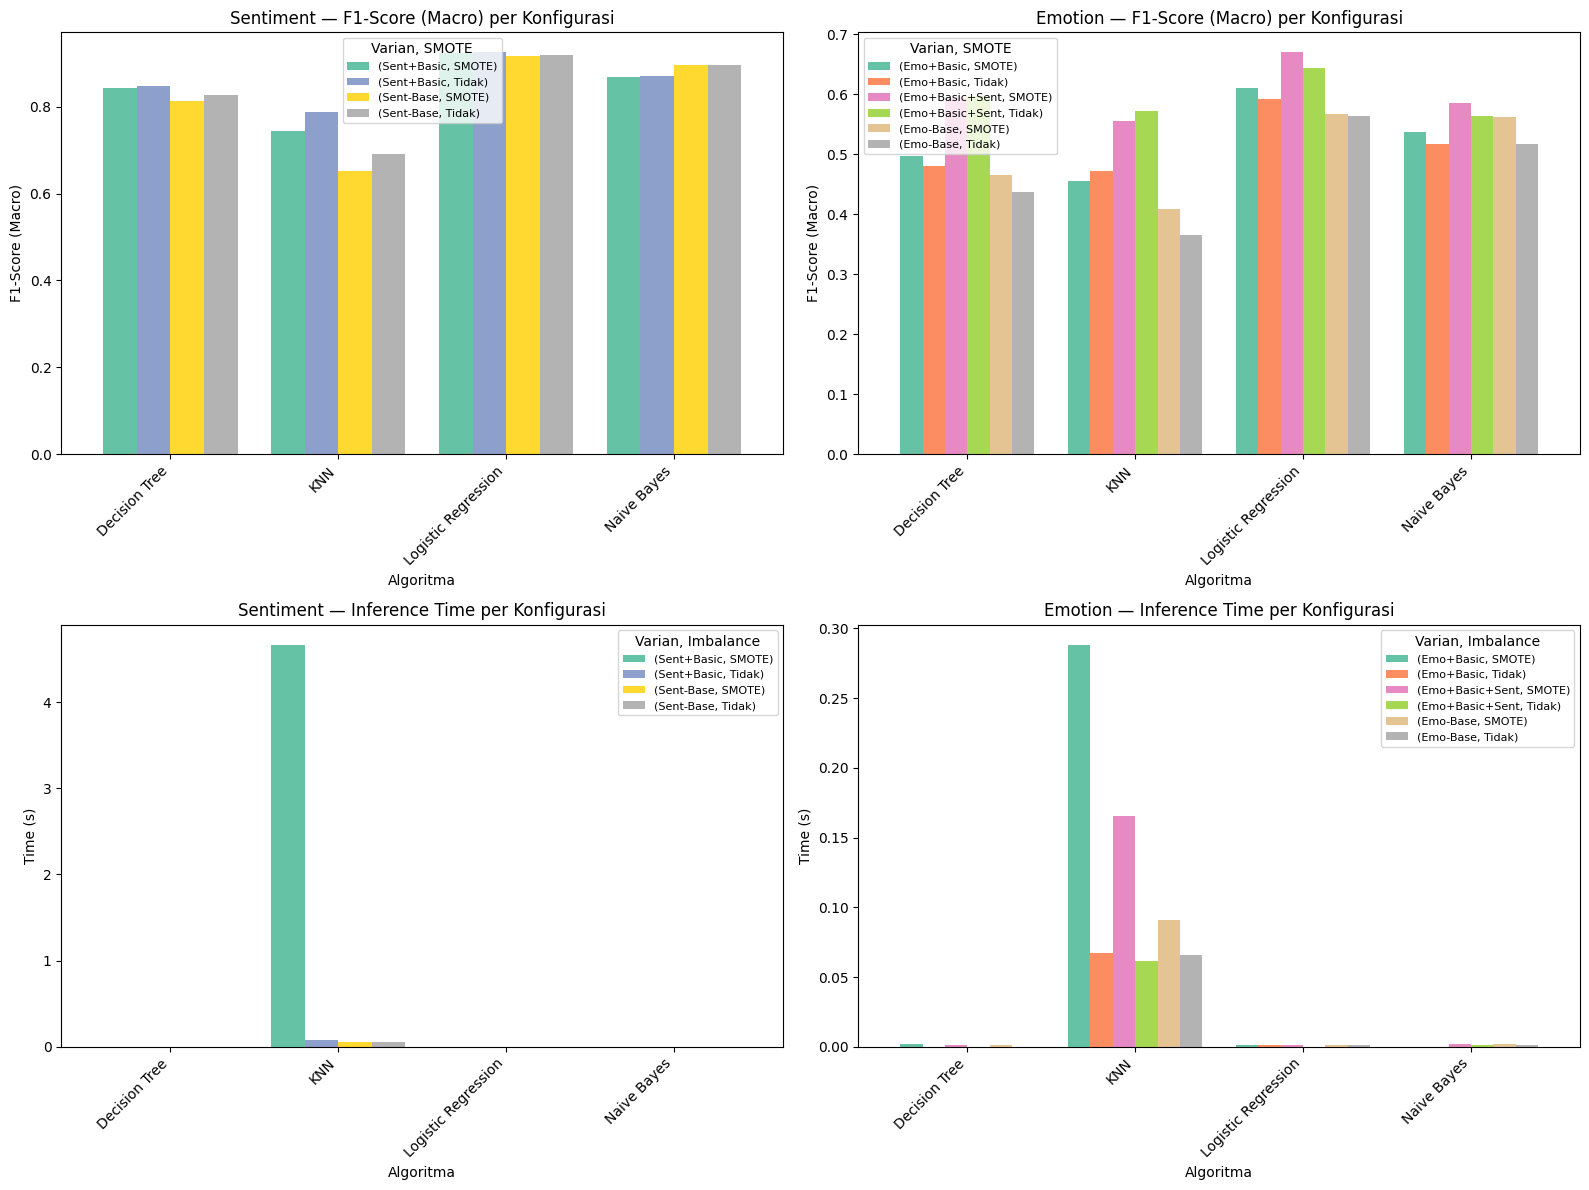

In [28]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sentiment F1
sent_f1 = df_results_sentiment.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
sent_f1.plot(kind='bar', ax=axes[0, 0], colormap='Set2', width=0.8)
axes[0, 0].set_title('Sentiment — F1-Score (Macro) per Konfigurasi')
axes[0, 0].set_ylabel('F1-Score (Macro)')
axes[0, 0].legend(title='Varian, SMOTE', fontsize=8)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

# 2. Emotion F1
emo_f1 = df_results_emotion.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='F1-Score (Macro)', aggfunc='first'
)
emo_f1.plot(kind='bar', ax=axes[0, 1], colormap='Set2', width=0.8)
axes[0, 1].set_title('Emotion — F1-Score (Macro) per Konfigurasi')
axes[0, 1].set_ylabel('F1-Score (Macro)')
axes[0, 1].legend(title='Varian, SMOTE', fontsize=8)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

# 3. Sentiment Inference Time
sent_time = df_results_sentiment.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='Inference Time (s)', aggfunc='first'
)
sent_time.plot(kind='bar', ax=axes[1, 0], colormap='Set2', width=0.8)
axes[1, 0].set_title('Sentiment — Inference Time per Konfigurasi')
axes[1, 0].set_ylabel('Time (s)')
axes[1, 0].legend(title='Varian, Imbalance', fontsize=8)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# 4. Emotion Inference Time
emo_time = df_results_emotion.pivot_table(
    index='Algoritma', columns=['Varian', 'Imbalance'],
    values='Inference Time (s)', aggfunc='first'
)
emo_time.plot(kind='bar', ax=axes[1, 1], colormap='Set2', width=0.8)
axes[1, 1].set_title('Emotion — Inference Time per Konfigurasi')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].legend(title='Varian, Imbalance', fontsize=8)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

> Yang menjadi temuan di sini adalah waktu inferensi sentimen oleh algoritma KN pada varian (Sent+Basic, SMOTE) sangat tinggi dibandingkan lainnya. Untuk waktu inferensi emosi, KNN (untuk semua variannya) juga mendominasi. Artinya, KNN yang selalu menghitung jarak data baru dengan data lama, lemah dalam bidang inferensi.


PERBANDINGAN EMOTION: FACTORIAL vs IMPROVED


,Set,Best F1-Macro
0,Factorial (Unigram+Basic),0.6700
1,Set A (Ngram+Enhanced),0.6661
2,Set B (Ngram+Enhanced+Ext),0.6509



--- Best per Algorithm ---

Factorial:
  Logistic Regression  | Emo+Basic+Sent       | SMOTE    | F1: 0.6700

Set A:
  Logistic Regression  | Emo-Ngram+Enh+Sent   | ADASYN   | F1: 0.6661

Set B:
  Logistic Regression  | Emo-Ngram+Enh+Sent   | ADASYN   | F1: 0.6509


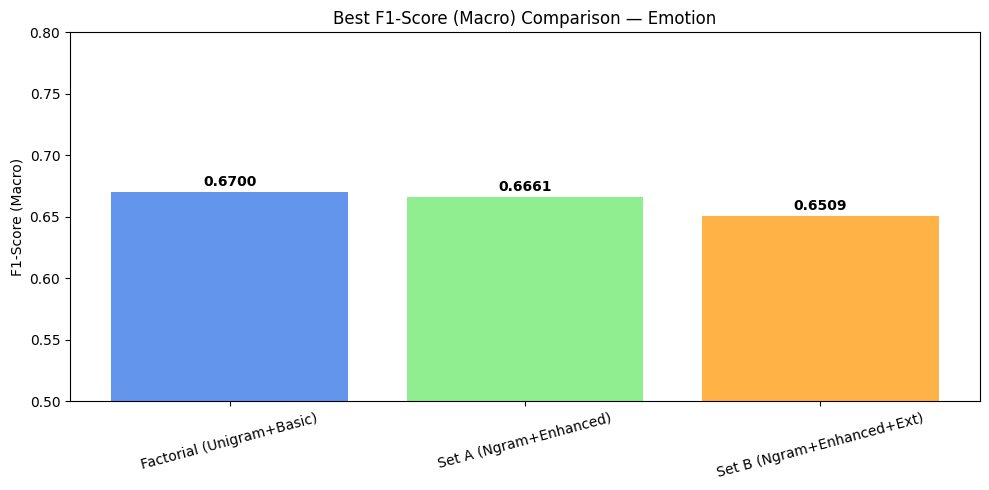

In [29]:
# Perbandingan Emotion: Factorial vs Improved
print("\n" + "=" * 90)
print("PERBANDINGAN EMOTION: FACTORIAL vs IMPROVED")
print("=" * 90)

best_factual = df_results_emotion['F1-Score (Macro)'].max()
best_set_a = df_results_emo_enh_base['F1-Score (Macro)'].max()
best_set_b = df_results_emo_enh_ext['F1-Score (Macro)'].max()

comparison = pd.DataFrame({
    'Set': ['Factorial (Unigram+Basic)', 'Set A (Ngram+Enhanced)', 'Set B (Ngram+Enhanced+Ext)'],
    'Best F1-Macro': [best_factual, best_set_a, best_set_b]
})
display(comparison)

print("\n--- Best per Algorithm ---")
all_emo_dfs = {
    'Factorial': df_results_emotion,
    'Set A':     df_results_emo_enh_base,
    'Set B':     df_results_emo_enh_ext,
}
for set_name, df_set in all_emo_dfs.items():
    best_row = df_set.loc[df_set['F1-Score (Macro)'].idxmax()]
    print(f"\n{set_name}:")
    print(f"  {best_row['Algoritma']:20s} | {best_row['Varian']:20s} | {best_row['Imbalance']:8s} | F1: {best_row['F1-Score (Macro)']:.4f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison['Set'], comparison['Best F1-Macro'], color=['#6495ED', '#90EE90', '#FFB347'])
ax.set_title('Best F1-Score (Macro) Comparison — Emotion')
ax.set_ylabel('F1-Score (Macro)')
ax.set_ylim(0.5, 0.8)
for i, v in enumerate(comparison['Best F1-Macro']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> Faktorial (unigram + fitur dasar + sentimen) justru unggul tipis (F1 67,0%) dibandingkan pendekatan improved ngram+enhanced (66,6%) dan extended grid (65,1%), menunjukkan bahwa kompleksitas fitur tambahan dan hyperparameter yang lebih luas tidak selalu meningkatkan performa pada kasus klasifikasi emosi multi-kelas yang tidak seimbang ini.

TOP 2 SENTIMENT MODELS — Classification Report & Confusion Matrix

>>> Rank #1: Logistic Regression | Sent+Basic | Tidak
Best Params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
F1-Score (Macro): 0.9249

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.94      0.93       557
    Positive       0.93      0.91      0.92       523

    accuracy                           0.93      1080
   macro avg       0.93      0.92      0.92      1080
weighted avg       0.93      0.93      0.92      1080



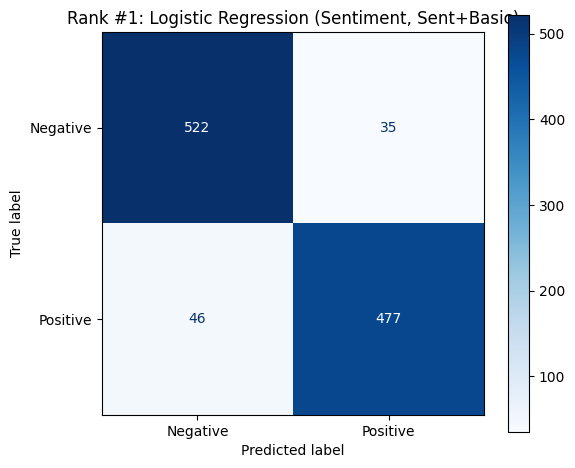


>>> Rank #2: Logistic Regression | Sent+Basic | SMOTE
Best Params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
F1-Score (Macro): 0.923

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.93      0.93       557
    Positive       0.93      0.91      0.92       523

    accuracy                           0.92      1080
   macro avg       0.92      0.92      0.92      1080
weighted avg       0.92      0.92      0.92      1080



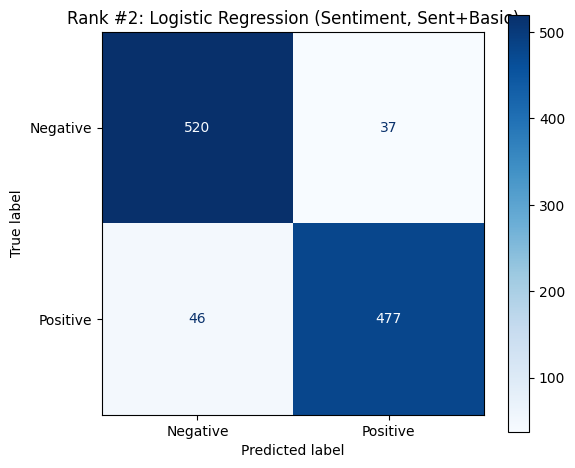

In [30]:
# Top 2 Sentiment Models — Classification Report & Confusion Matrix
print("=" * 70)
print("TOP 2 SENTIMENT MODELS — Classification Report & Confusion Matrix")
print("=" * 70)

sent_var_map = {
    'Sent-Base':  X_sent_base_te,
    'Sent+Basic': X_sent_basic_te,
}

for rank in [0, 1]:
    row = sentiment_ranked.iloc[rank]
    use_smote = row['Imbalance'] in ['SMOTE', 'Ya']
    key = (row['Algoritma'], row['Varian'], use_smote)
    info = best_models_sentiment[key]
    est = info['best_estimator']
    pred = info['y_pred']
    X_te = sent_var_map[row['Varian']]

    print(f"\n>>> Rank #{rank+1}: {row['Algoritma']} | {row['Varian']} | {row['Imbalance']}")
    print(f"Best Params: {row['Best Params']}")
    print(f"F1-Score (Macro): {row['F1-Score (Macro)']}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_sen, pred))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(est, X_te, y_test_sen, ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"Rank #{rank+1}: {row['Algoritma']} (Sentiment, {row['Varian']})")
    plt.tight_layout()
    plt.show()

> Dua model sentimen terbaik (Logistic Regression Sent+Basic, tanpa dan dengan SMOTE) menunjukkan performa hampir identik di atas 92% untuk semua metrik, dengan model tanpa SMOTE unggul tipis (F1 92,5% vs 92,3%) dan waktu inferensi lebih cepat, sementara SMOTE tidak memberikan perbaikan berarti karena dataset sentimen sudah relatif seimbang (557 negatif vs 523 positif).


TOP 2 EMOTION MODELS — Classification Report & Confusion Matrix

>>> Rank #1: Logistic Regression | Emo+Basic+Sent | SMOTE
Best Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
F1-Score (Macro): 0.67

Classification Report:
              precision    recall  f1-score   support

       Anger       0.58      0.52      0.55       145
        Fear       0.47      0.58      0.52       159
       Happy       0.88      0.85      0.87       356
        Love       0.71      0.75      0.73       167
     Sadness       0.72      0.65      0.68       253

    accuracy                           0.71      1080
   macro avg       0.67      0.67      0.67      1080
weighted avg       0.71      0.71      0.71      1080



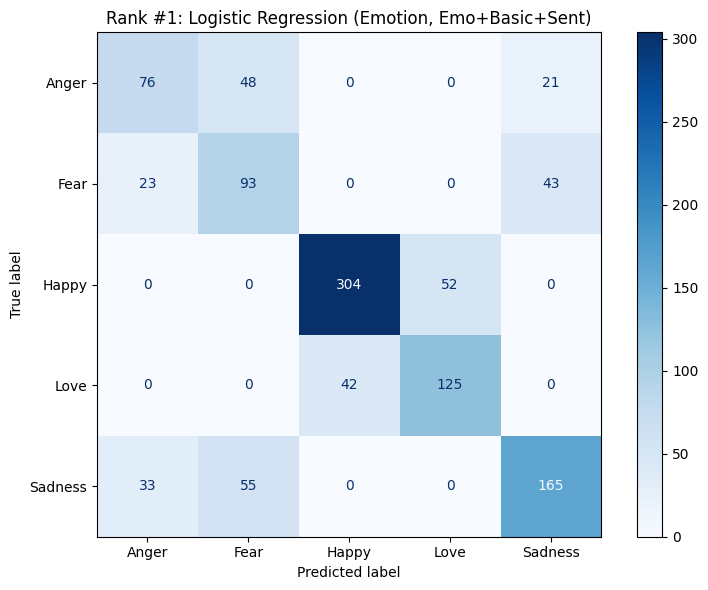


>>> Rank #2: Logistic Regression | Emo+Basic+Sent | Tidak
Best Params: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
F1-Score (Macro): 0.6436

Classification Report:
              precision    recall  f1-score   support

       Anger       0.58      0.41      0.48       145
        Fear       0.47      0.52      0.49       159
       Happy       0.83      0.91      0.87       356
        Love       0.77      0.60      0.68       167
     Sadness       0.66      0.73      0.69       253

    accuracy                           0.70      1080
   macro avg       0.66      0.64      0.64      1080
weighted avg       0.70      0.70      0.69      1080



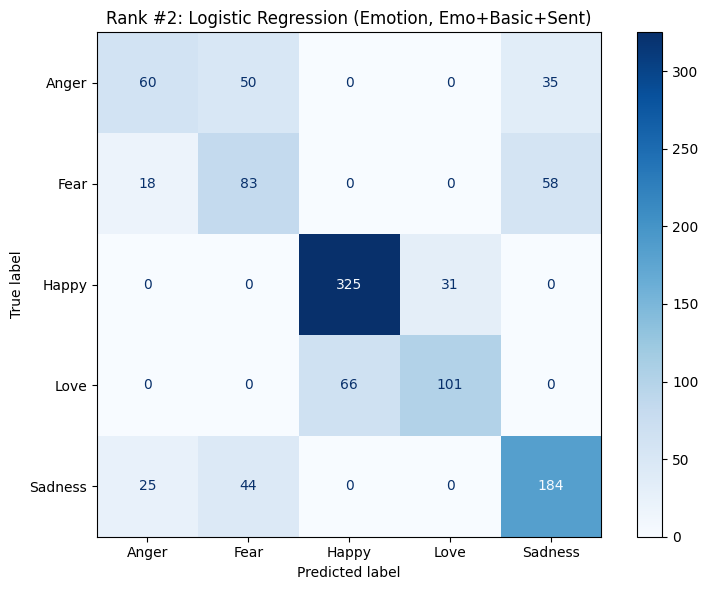

In [31]:
# Top 2 Emotion Models — Classification Report & Confusion Matrix
print("\n" + "=" * 70)
print("TOP 2 EMOTION MODELS — Classification Report & Confusion Matrix")
print("=" * 70)

emo_var_map = {
    'Emo-Base':       X_emo_base_te,
    'Emo+Basic':      X_emo_basic_te,
    'Emo+Basic+Sent': X_emo_basic_sent_te,
}

for rank in [0, 1]:
    row = emotion_ranked.iloc[rank]
    use_smote = row['Imbalance'] in ['SMOTE', 'Ya']
    key = (row['Algoritma'], row['Varian'], use_smote)
    info = best_models_emotion[key]
    est = info['best_estimator']
    pred = info['y_pred']
    X_te = emo_var_map[row['Varian']]

    print(f"\n>>> Rank #{rank+1}: {row['Algoritma']} | {row['Varian']} | {row['Imbalance']}")
    print(f"Best Params: {row['Best Params']}")
    print(f"F1-Score (Macro): {row['F1-Score (Macro)']}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_emo, pred))

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(est, X_te, y_test_emo, ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"Rank #{rank+1}: {row['Algoritma']} (Emotion, {row['Varian']})")
    plt.tight_layout()
    plt.show()

> Model emosi terbaik (Logistic Regression dengan SMOTE, F1 67%) unggul karena SMOTE meningkatkan recall Fear dari 52% ke 58% dan Anger dari 41% ke 52%, sementara kelas Happy paling mudah diprediksi (F1 87%) dan Fear paling sulit (F1 52%) akibat ketidakseimbangan kelas dan tumpang tindih semantik antar emosi negatif.

In [32]:
# Save Best Models
model_dir = Path("../model")
sent_dir = model_dir / "sentiment"
emo_dir = model_dir / "emotion"
sent_dir.mkdir(parents=True, exist_ok=True)
emo_dir.mkdir(parents=True, exist_ok=True)

# 1. Best Sentiment Model
best_sent_row = sentiment_ranked.iloc[0]
use_smote = best_sent_row['Imbalance'] in ['SMOTE', 'Ya']
best_sent_key = (best_sent_row['Algoritma'], best_sent_row['Varian'], use_smote)
best_sent_est = best_models_sentiment[best_sent_key]['best_estimator']

joblib.dump(best_sent_est, sent_dir / "inference_v1.joblib")
joblib.dump(vectorizer, sent_dir / "vectorizer_v1.joblib")
print(f"Sentiment saved: {best_sent_row['Algoritma']} (F1={best_sent_row['F1-Score (Macro)']})")

# 2. Best Emotion Model (across all sets)
all_emo_dfs = {
    'Factorial': df_results_emotion,
    'Set A':     df_results_emo_enh_base,
    'Set B':     df_results_emo_enh_ext,
}
best_emo_overall = None
best_f1 = -1
best_set_name = ''
for set_name, df_set in all_emo_dfs.items():
    row = df_set.loc[df_set['F1-Score (Macro)'].idxmax()]
    if row['F1-Score (Macro)'] > best_f1:
        best_f1 = row['F1-Score (Macro)']
        best_emo_overall = row
        best_set_name = set_name

emo_dict_map = {
    'Factorial': best_models_emotion,
    'Set A':     best_emo_enh_base,
    'Set B':     best_emo_enh_ext,
}
imb_str = best_emo_overall['Imbalance'].lower()
imb_str = {'tidak': 'none', 'ya': 'smote'}.get(imb_str, imb_str)

# Factorial uses boolean keys, improved sets use string keys
if best_set_name == 'Factorial':
    use_smote = imb_str == 'smote'
    best_emo_key = (best_emo_overall['Algoritma'], best_emo_overall['Varian'], use_smote)
else:
    best_emo_key = (best_emo_overall['Algoritma'], best_emo_overall['Varian'], imb_str)

best_emo_est = emo_dict_map[best_set_name][best_emo_key]['best_estimator']

# Determine vectorizer & feature extractor
if best_set_name == 'Factorial':
    emo_vec = vectorizer
    emo_feat = extract_emotion_features
else:
    emo_vec = vectorizer_ng
    emo_feat = extract_emotion_features_enhanced

joblib.dump(best_emo_est, emo_dir / "inference_v1.joblib")
joblib.dump(emo_vec, emo_dir / "vectorizer_v1.joblib")
joblib.dump(emo_feat, emo_dir / "emotion_feature_extractor_v1.joblib")
print(f"Emotion saved: {best_emo_overall['Algoritma']} ({best_set_name}, F1={best_f1})")

Sentiment saved: Logistic Regression (F1=0.9249)
Emotion saved: Logistic Regression (Factorial, F1=0.67)


> Model terbaik untuk sentimen (Logistic Regression, F1 92,5%) dan emosi (Logistic Regression dengan SMOTE, F1 67,0%) beserta vektorisator dan ekstraktor fitur yang sesuai telah disimpan ke direktori terpisah.